# Modelos de Potencial Intermolecular para el Deuterio (D₂)
---



In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.integrate import quad
from sklearn.metrics import r2_score, mean_squared_error

sigma = 2.928e-10        #  [m]
Na    = 6.022e23         # [molecules/mol]
kB    = 1.380649e-23     # [J/K]


C:\Users\premz\AppData\Local\Temp\ipykernel_28440\195438412.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=11)


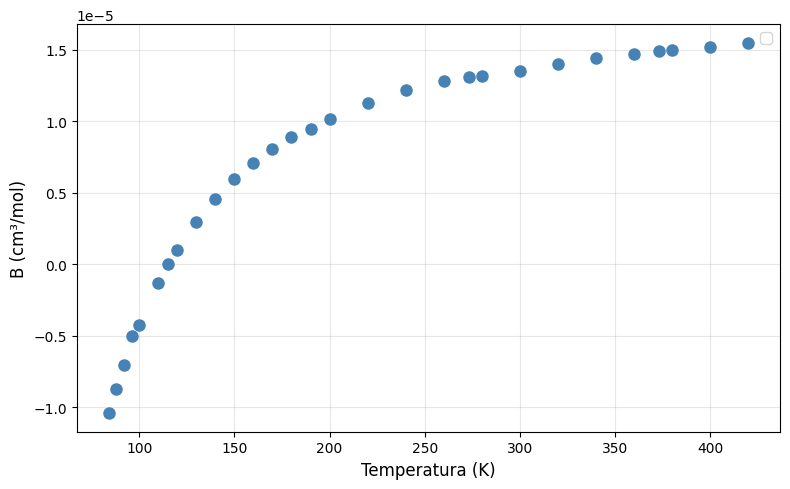

In [31]:
df = pd.read_excel('Datos Deuterio.xlsx')
T_data = df['T'].to_numpy()   # [K]
B_data = df['B'].to_numpy()   # [cm³/mol] -> Me esta generando inconsistencia de unidades
B_data = B_data*(1/100)**3    # [m³/mol]

plt.figure(figsize=(8, 5))
plt.plot(T_data, B_data, 'o', color='steelblue', markersize=8)
plt.xlabel('Temperatura (K)', fontsize=12)
plt.ylabel('B (cm³/mol)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Optimization terminated successfully.
         Current function value: 0.000000
         Iterations: 4953
         Function evaluations: 9108

  Pozo Cuadrado 
  ε   = 1.402245e-27 J  
  a  = 3.112167e-08 m 

  R² = 0.744737


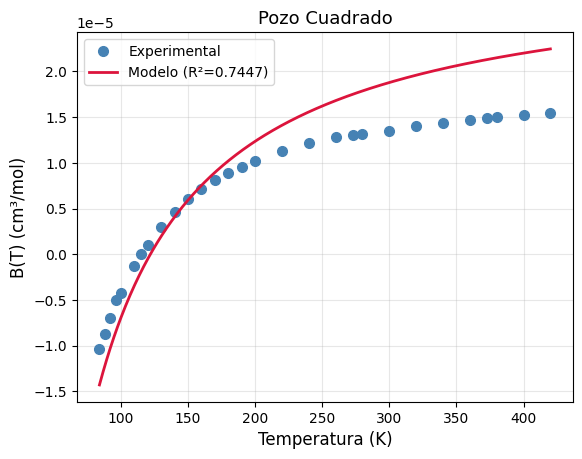

In [32]:
def B_pozoCuadrado(params, T):
    epsilon, a = params
    B_m3 = (2 * np.pi * Na / 3) * (
        sigma**3 + (a**3 - sigma**3) * (1 - np.exp(epsilon / (kB * T)))
    )
    return B_m3

def calc_SSE(params, T, B_exp):
    residuals = B_exp - B_pozoCuadrado(params, T)
    return 0.5 * np.dot(residuals, residuals)

epsilon_0 = 35.0 * kB        # [J]  →  ε/kB ≈ 35 K
a_0       = 1.6 * sigma      # [m]  →  λ = a/σ ≈ 1.6
params_0  = [epsilon_0, a_0]



result_SW = minimize(calc_SSE, params_0, args=(T_data, B_data),
                     method='Nelder-Mead',
                     options={'disp': True, 'maxiter': 50000,
                              'xatol': 1e-15, 'fatol': 1e-12})

eps_fit, a_fit = result_SW.x
print(f"\n{'='*55}")
print(f"  Pozo Cuadrado ")
print(f"{'='*55}")
print(f"  ε   = {eps_fit:.6e} J  ")
print(f"  a  = {a_fit:.6e} m ")
print(f"{'='*55}")

B_pred_SW = B_pozoCuadrado([eps_fit, a_fit], T_data)
R2_SW     = r2_score(B_data, B_pred_SW)
print(f"\n  R² = {R2_SW:.6f}")

T_smooth   = np.linspace(T_data.min(), T_data.max(), 500)
B_model_SW = B_pozoCuadrado([eps_fit, a_fit], T_smooth)

# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plt.plot(T_data, B_data, 'o', color='steelblue', ms=7, label='Experimental')
plt.plot(T_smooth, B_model_SW, '-', color='crimson', lw=2,
             label=f'Modelo (R²={R2_SW:.4f})')
plt.xlabel('Temperatura (K)', fontsize=12)
plt.ylabel('B(T) (cm³/mol)', fontsize=12)
plt.title('Pozo Cuadrado', fontsize=13)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.show()

In [34]:
# ── Integracion Numerica ──────────────────
def potential2(r, epsilon, m):
    C = epsilon * (m / (m - 6)) * (m / 6) ** (6 / (m - 6))
    return C * ((sigma / r) ** m - (sigma / r) ** 6)


def B_2(params, T_arr):        
    hard_core = sigma**3 / 3.0 #valor de esfera rigida asumiendo que potencial infinito a r menor que sigma -> 
    epsilon, m = params
    results = []
    
    for T in np.atleast_1d(T_arr):
        def integral(r):
            u = potential2(r, epsilon, m)
            return (1.0 - (np.exp(-u / (kB * T)))) * r**2 
        
        soft_part, _= quad(integral, sigma, 50 * sigma, limit=500) # para facilitar optimizacion aumento limite inicial a sigma, para que no lidie con valores infinitos
        
        B_val = 2 * np.pi * Na * (hard_core + soft_part)  # [m³/mol]
        # B_val = 2 * np.pi * Na * (soft_part)  # [m³/mol]
        results.append(B_val)  
    
    return np.array(results)



C:\Users\premz\AppData\Local\Temp\ipykernel_28440\712971071.py:3: RuntimeWarning: invalid value encountered in scalar power
  C = epsilon * (m / (m - 6)) * (m / 6) ** (6 / (m - 6))
C:\Users\premz\AppData\Local\Temp\ipykernel_28440\712971071.py:17: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  soft_part, _= quad(integral, sigma, 50 * sigma, limit=500) # para facilitar optimizacion aumento limite inicial a sigma, para que no lidie con valores infinitos


Optimization terminated successfully.
         Current function value: 0.000000
         Iterations: 138
         Function evaluations: 316

  Parametros
  ε              = 1.446051e-26 J 
  m              = 0.0282
  SSE            = 2.346681e-10

  R² = 0.744734


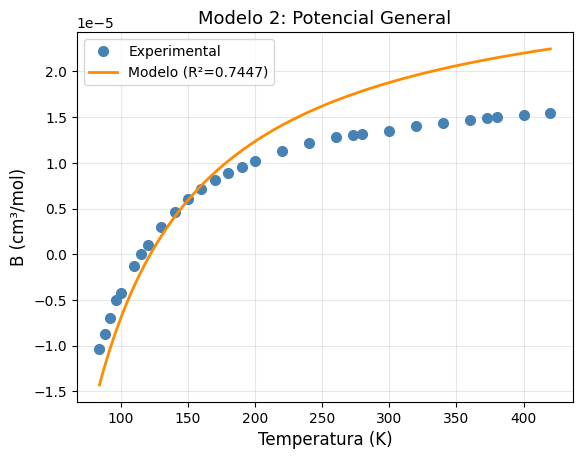

In [35]:
def calc_SSE_2(params, T, B_exp):
    residuals = B_exp - B_2(params, T)
    return 0.5 * np.dot(residuals, residuals)

eps2_0 = eps_fit      
m_0  = 12.0     #probando varios, este me funcino bien       
params2_0 = [eps2_0, m_0]

result_2 = minimize(calc_SSE_2, params2_0, args=(T_data, B_data),
                      method='Nelder-Mead',
                      options={'disp': True, 'maxiter': 100000,
                               'xatol': 1e-15, 'fatol': 1e-10})

eps2_fit, m_fit = result_2.x
print(f"\n{'='*55}")
print(f"  Parametros")
print(f"{'='*55}")
print(f"  ε              = {eps2_fit:.6e} J ")
print(f"  m              = {m_fit:.4f}")
print(f"  SSE            = {result_2.fun:.6e}")
print(f"{'='*55}")


B_pred_2 = B_2([eps2_fit, m_fit], T_data)
R2_2     = r2_score(B_data, B_pred_2)
print(f"\n  R² = {R2_2:.6f}")

B_model_2 = B_2([eps2_fit, m_fit], T_smooth)


plt.plot(T_data, B_data, 'o', color='steelblue', ms=7, label='Experimental')
plt.plot(T_smooth, B_model_2, '-', color='darkorange', lw=2,
             label=f'Modelo (R²={R2_2:.4f})')
plt.xlabel('Temperatura (K)', fontsize=12)
plt.ylabel('B (cm³/mol)', fontsize=12)
plt.title('Modelo 2: Potencial General', fontsize=13)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.show()

In [6]:
!pip install chemicals

# Coeficientes de ecuacion de estado con coeficientes de virial

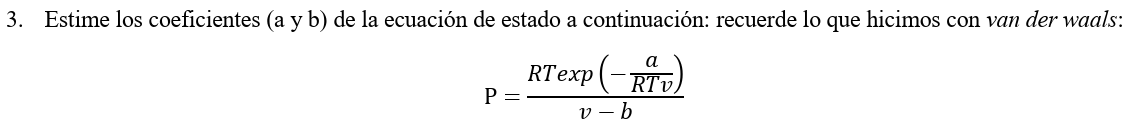

In [36]:
def stateEq(T, a, b, R, v):
    return (T*R*(np.exp(-1*a/(R*T*v))))/(v-b)

from chemicals import Pc, Vc, Tc

casNumber = 7782390

def error(params, T, B):
    residuals = B - eq(params[0], params[1], T)
    return np.sum(residuals**2)


R_cst = 8.3145 #J/m^3*K

def eq(a, b, T):
    return (-1*a/(R_cst*T)) + b


#como valores iniciales vamos a usar el resultado de las constantes criticas

a_crit = (2*R_cst*Tc(casNumber)*Vc(casNumber))
b_crit = (1/2)*Vc(casNumber)
params = [a_crit, b_crit]

print(f"{'='*55}")
print("Parametros con punto critico")
print(f"{'='*55}")
print(f"a: {a_crit}")
print(f"b: {b_crit}")
print(f"{'='*55}" + "\n")



result_2 = minimize(error, params, args=(T_data, B_data),
                      method='Nelder-Mead',
                      options={'disp': True, 'maxiter': 10000,
                               'xatol': 1e-15, 'fatol': 1e-10})

a_vir, b_vir = result_2.x

print("\n" + f"{'='*55}")
print("Parametros con coeficiente de virial")
print(f"{'='*55}")
print("a: ", a_vir)
print("b: ", b_vir)
print(f"{'='*55}")



Parametros con punto critico
a: 0.03173128652369458
b: 2.2472e-05

Optimization terminated successfully.
         Current function value: 0.000000
         Iterations: 93
         Function evaluations: 197

Parametros con coeficiente de virial
a:  0.02219818684245491
b:  2.2812994024613405e-05


# Graficas Parametros de Virial vs Parametros de punto criticos 

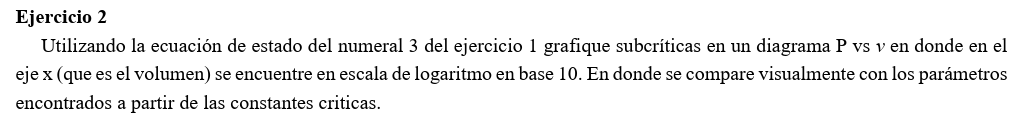


C:\Users\premz\AppData\Local\Temp\ipykernel_28440\3570482945.py:2: RuntimeWarning: divide by zero encountered in divide
  return (T*R*(np.exp(-1*a/(R*T*v))))/(v-b)


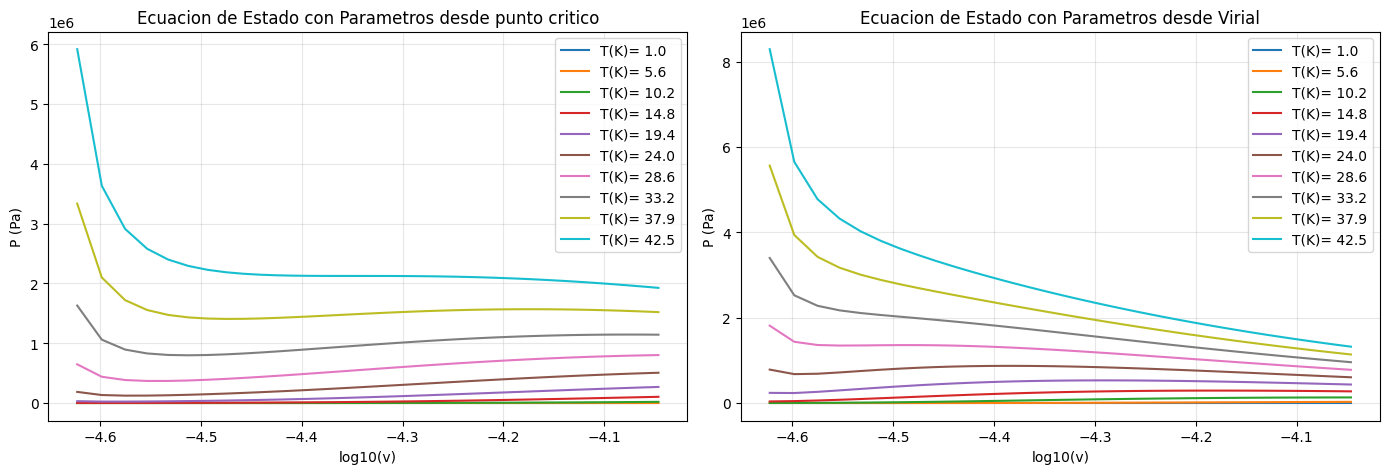

In [37]:
# fig, axes = plt.subplot(1, 2, figsize=(Vc(7782390) + 1, Pc(7782390) + 50)) #P[Pa], V[m^3]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

T_smooth_plot = np.linspace(1, Tc(casNumber), 10)  # pocas para que sea facil de ver, y desde 10, 
                                                   #porque el punto critico es 42 K, y el dato minimo de la tabla no lo alcanza a cubrir.
                                                   # osea, los datos de la tabla estna por encima de la temperatura critica.
V_smooth = np.linspace(b_crit, 2*Vc(casNumber), 50)
V_log10 = np.log10(V_smooth)


for t in T_smooth_plot:
    eqCrit = stateEq(t, a_crit, b_crit, R_cst, V_smooth)
    axes[0].plot(V_log10, eqCrit, label=f"T(K)= {t:.1f}")
    axes[0].set_xlabel('log10(v)')
    # v(m^3/mol)
    axes[0].set_ylabel('P (Pa)')
    axes[0].set_title('Ecuacion de Estado con Parametros desde punto critico')
    axes[0].grid(True, alpha=0.3)
    # axes[0].plot(Pc(casNumber), np.log10(Vc(casNumber)),'o')
    axes[0].legend(fontsize=10)



V_smooth = np.linspace(b_vir, 5*Vc(casNumber), 50) #En la de virial, lo ajustare a el b de virial
# V_log10 = np.log10(V_smooth)
for t in T_smooth_plot:    
    eqVirial = stateEq(t, a_vir, b_vir, R_cst, V_smooth)
    axes[1].plot(V_log10, eqVirial, label=f"T(K)= {t:.1f}")
    axes[1].set_xlabel('log10(v)')
    #v(m^3/mol)
    axes[1].set_ylabel('P (Pa)')
    axes[1].set_title('Ecuacion de Estado con Parametros desde Virial')
    # axes[1].plot(Pc(casNumber), np.log10(Vc(casNumber)),'o')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(fontsize=10)



plt.tight_layout()
plt.show()





In [27]:
# A tener en cuenta
import chemicals

print(f"Tc Deuterio: {chemicals.Tc(casNumber)} K")
print(f"Pc Deuterio: {chemicals.Pc(casNumber)} Pa")
print(f"Vc Deuterio: {chemicals.Vc(casNumber)} m^3/mol")

Tc Deuterio: 42.457051 K
Pc Deuterio: 2249543.9 Pa
Vc Deuterio: 4.4944e-05 m^3/mol
